# 02 — Mixing Waves and Fourier Series

## Learning goals

- See a periodic function as a sum of harmonics.
- Understand the fundamental frequency $\omega_1 = 2\pi/T$.
- Build a signal from amplitude and phase spectra.
- Approximate a square wave by adding more and more sinusoids.

## Mental model

A Fourier series is a mixing board. Each harmonic has a volume slider and a timing knob. The waveform you hear or see is what comes out after all sliders and timing knobs are combined.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (9, 4.8)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

def stem_spectrum(freqs, values, title="Spectrum", xlabel="Frequency", ylabel="Amplitude"):
    fig, ax = plt.subplots(figsize=(9, 4.5))
    markerline, stemlines, baseline = ax.stem(freqs, values, basefmt=" ")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True)
    plt.show()

## The fundamental and its harmonics

A periodic signal with period $T$ has a lowest nonzero frequency

$$\nu_1 = \frac{1}{T}, \qquad \omega_1 = \frac{2\pi}{T}.$$

The allowed harmonics are integer multiples:

$$\omega_n = n\omega_1.$$

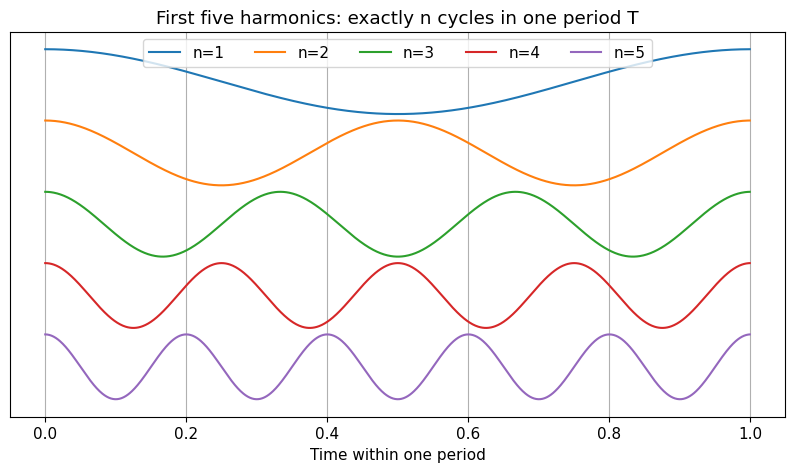

In [2]:
T = 1.0
t = np.linspace(0, T, 1000, endpoint=False)

fig, ax = plt.subplots(figsize=(10, 5))
for n in range(1, 6):
    ax.plot(t, np.cos(2*np.pi*n*t/T) + 2.2*(5-n), label=f"n={n}")
ax.set_title("First five harmonics: exactly n cycles in one period T")
ax.set_xlabel("Time within one period")
ax.set_yticks([])
ax.legend(ncol=5, loc="upper center")
plt.show()

## Build a function from amplitude and phase spectra

Here we choose five amplitudes and five phases. The time-domain function is

$$f(t) = \sum_{n=1}^{5} A_n\cos(2\pi n t/T - \phi_n).$$

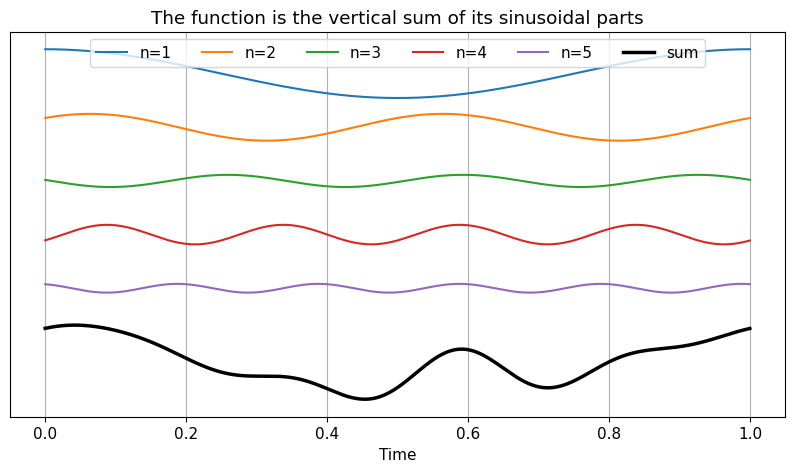

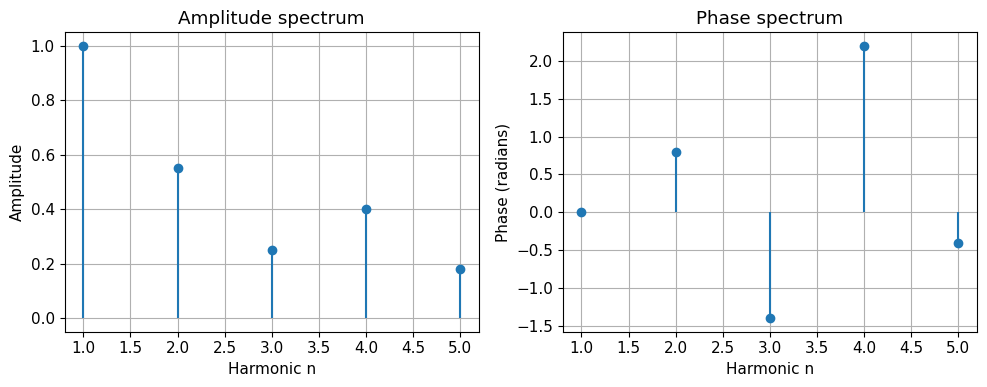

In [3]:
A = np.array([1.0, 0.55, 0.25, 0.40, 0.18])
phi = np.array([0.0, 0.8, -1.4, 2.2, -0.4])
components = []
for n, (An, phin) in enumerate(zip(A, phi), start=1):
    components.append(An*np.cos(2*np.pi*n*t/T - phin))
components = np.array(components)
f = components.sum(axis=0)

fig, ax = plt.subplots(figsize=(10, 5))
for n, comp in enumerate(components, start=1):
    ax.plot(t, comp + 2.2*(5-n), label=f"n={n}")
ax.plot(t, f - 3.0, color="black", linewidth=2.5, label="sum")
ax.set_title("The function is the vertical sum of its sinusoidal parts")
ax.set_xlabel("Time")
ax.set_yticks([])
ax.legend(ncol=6, loc="upper center")
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].stem(np.arange(1, 6), A, basefmt=" ")
axs[0].set_title("Amplitude spectrum")
axs[0].set_xlabel("Harmonic n")
axs[0].set_ylabel("Amplitude")
axs[1].stem(np.arange(1, 6), phi, basefmt=" ")
axs[1].set_title("Phase spectrum")
axs[1].set_xlabel("Harmonic n")
axs[1].set_ylabel("Phase (radians)")
plt.tight_layout()
plt.show()

## Nonzero mean = the zero-frequency component

Every sine and cosine oscillates around zero. To represent a function with a nonzero mean, add a constant term.

The zero-frequency term is usually written $C_0/2$ or $A_0/2$.

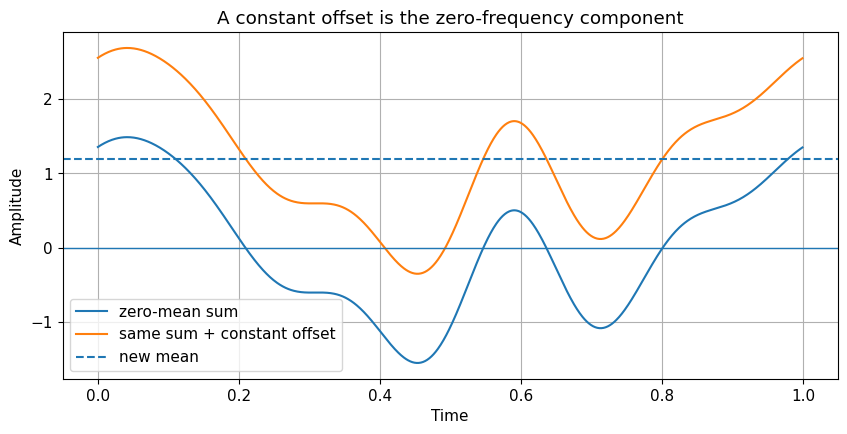

Mean of f: -0.0
Mean after adding offset: 1.2


In [4]:
mean_offset = 1.2
g = mean_offset + f

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(t, f, label="zero-mean sum")
ax.plot(t, g, label="same sum + constant offset")
ax.axhline(0, linewidth=1)
ax.axhline(mean_offset, linestyle="--", label="new mean")
ax.set_title("A constant offset is the zero-frequency component")
ax.set_xlabel("Time")
ax.set_ylabel("Amplitude")
ax.legend()
plt.show()

print("Mean of f:", f.mean().round(6))
print("Mean after adding offset:", g.mean().round(6))

## Approximating a square wave

A square wave can be built from infinitely many odd sine harmonics:

$$\mathrm{square}(t) \approx \frac{4}{\pi}\left[\sin(2\pi t) + \frac{1}{3}\sin(6\pi t) + \frac{1}{5}\sin(10\pi t) + \cdots\right].$$

More harmonics give a sharper edge. Near the jump there is overshoot: this is the Gibbs phenomenon.

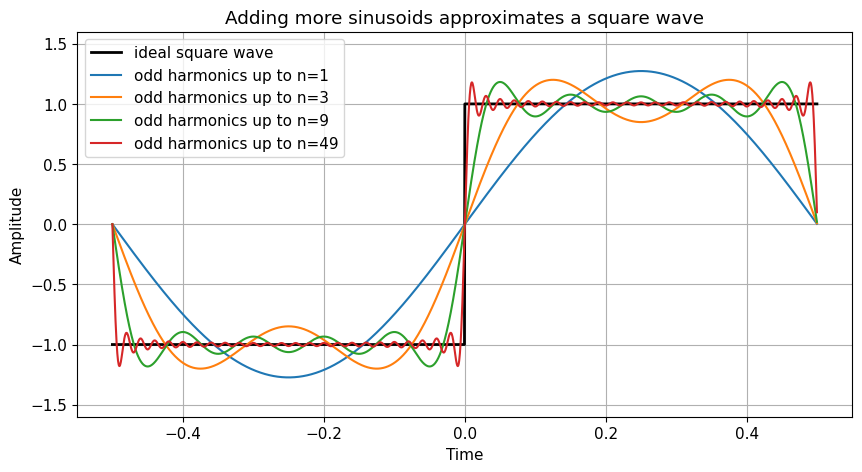

In [5]:
t = np.linspace(-0.5, 0.5, 2000, endpoint=False)
target = np.where(np.sin(2*np.pi*t) >= 0, 1, -1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t, target, color="black", linewidth=2, label="ideal square wave")

for K in [1, 3, 9, 49]:
    odd_ns = np.arange(1, K+1, 2)
    approx = np.zeros_like(t)
    for n in odd_ns:
        approx += (4/np.pi) * np.sin(2*np.pi*n*t) / n
    ax.plot(t, approx, label=f"odd harmonics up to n={K}")

ax.set_title("Adding more sinusoids approximates a square wave")
ax.set_xlabel("Time")
ax.set_ylabel("Amplitude")
ax.set_ylim(-1.6, 1.6)
ax.legend(loc="upper left")
plt.show()

## Checkpoint

1. Add even harmonics to the square-wave approximation. Do they help?
2. Change the phases in the five-component example. Can you make the same amplitude spectrum produce a different-looking waveform?
3. Add a constant offset to the square wave. Which Fourier component should represent it?